# QUbitization + Chebychev Polynomial + Qubitized Walk
----

## 数学原理

### 1. 从Block Encoding 到 Qubitization
上一节已经有
$$
(\bra{0^a}\otimes I)U_A(\ket{0^a}\otimes I)=\frac{A}{\alpha}
$$
定义 $B=\frac{A}{\alpha}$, 于是有
$$
\|B\|\leq 1
$$
Block Encoding 可以简单理解为
$$
B\to U_A
$$
但是问题是:
> B 的本征值藏在 $U_A$ 的矩阵块中, 如何让量子线路"感受到"这些本征值

这就是 Qubitization 的目标. 

它把 $x=\lambda/\alpha$ 转化为一个二维旋转角 $x=\cos\theta$, 于是有
$$
\lambda/\alpha\to\theta\to e^{\pm i\theta}
$$

### 2. 本节实验矩阵
本节所采用一个非常小的 Hermitian 矩阵, 为
$$
A=\begin{bmatrix}
0.6 & 0.2 \\
0.2 & 0.2
\end{bmatrix}
$$
它的本征值为
$$
\lambda_{\pm}=0.4\pm \sqrt{0.08}
$$
大约为 $\lambda_1\approx 0.682843, \lambda_2\approx 0.117157$, 都落在 $[-1, 1]$ 内. 因此 A 是压缩算子.

数学推导中选取 $\alpha=1$, 但是在官方实验中, 选取 `be_result.alpha`

Official alpha = 1.0
Total qubits = 2
Target qubits = 1


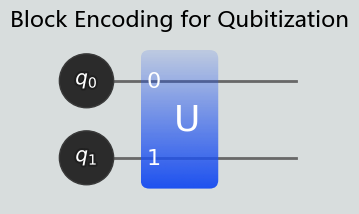

In [4]:
# 绘制官方线路
import numpy as np
from unitarylab.library import block_encode

%matplotlib inline

A = np.array([[0.6, 0.2], [0.2, 0.2]], dtype=complex)
be_result = block_encode(A, method="nagy", eps=1e-12, verbose=False)

be_circuit = be_result.circuit
alpha = be_result.alpha

print("Official alpha =", alpha)
print("Total qubits =", be_result.total_qubits)
print("Target qubits =", be_result.target_qubits)

_ = be_circuit.draw(title="Block Encoding for Qubitization")

### 3. 为什么 Qubitiation 不是简单地重复 $U_A$?
如果直接执行
$$
U_A^2, U_A^3, \cdots
$$
通常不会得到
$$
A^2, A^3, \cdots
$$
一般成立
$$
(U_A^n)_{00}\neq (A/\alpha)^n
$$
所以 Qubitization 的关键就是加入一个 reflection.

### 4. 最简单的 signal-unitary 模型
定义 $B=A/\alpha$, 对 Hermitian contraction B, 构造
$$
U_B=\begin{bmatrix}
B & \sqrt{I-B^2} \\
\sqrt{I-B^2} & -B
\end{bmatrix}
$$
该矩阵满足
$$
U_B^\dagger U_B=I,\quad U_B^2=I
$$
所以它本身是一个 **类反射信号酉算子**.

### 5. 为什么此 dilation 能 block-encode B?
定义 ancilla projector:
$$
\Pi=\ket{0}\bra{0}\otimes I
$$
显然有
$$
\Pi U_B \Pi = B
$$
在投影后的 system space 上. 即
$$
(\bra{0}\otimes I)U_B(\ket{0}\otimes I)=B
$$

### 6. 定义 Qubitization reflection
定义
$$
R=2\Pi -I
$$
对于一个 ancilla qubit:
$$
R=\begin{bmatrix}
I & 0 \\
0 & -I
\end{bmatrix}
$$
然后定义 qubitized walk:
$$
W=R U_B
$$
不同文献可以能写 $W=U_B R$ 或整体差一个符号, 但其不会改变核心的特征相位关系.

### 7. 先看一个标量 $x$.
假设
$$
B\ket{\lambda}=x\ket{\lambda},\quad x\in[-1,1]
$$
在与这个本征态对应的二维不变子空间中
$$
U_B\to \begin{bmatrix}
x & \sqrt{1-x^2} \\
\sqrt{1-x^2} & -x
\end{bmatrix}
$$
因此 $W=R U_B$ 变成
$$
W(x)=\begin{bmatrix}
x & \sqrt{1-x^2} \\
-\sqrt{1-x^2} & x
\end{bmatrix}
$$

### 8. Qubitization 最重要一步
因为 $x\in[-1,1]$,可以写
$$
x=\cos\theta
$$
因此
$$
W(x)=\begin{bmatrix}
\cos\theta & \sin\theta \\
-\sin\theta & \cos\theta
\end{bmatrix}
$$
也就是说 $W(x)$ 是一个由 $\theta$ 控制的二维旋转矩阵. 所以本征值为
$$
e^{\pm i\theta}
$$
即
$$
x\to \theta=\arccos(x)\to e^{\pm i\theta}
$$
这就是 Qubitization 的核心作用.

### 9. Chebyshev 的出现
在重复执行 qubitized walk 时, 因为其是二维旋转
$$
W(x)^n=\begin{bmatrix}
\cos(n\theta) & \sin(n\theta) \\
-\sin(n\theta) & \cos(n\theta)
\end{bmatrix}
$$
并且 Chebyshev 多项式的定义为
$$
T_n(x)=\cos(n\arccos x)=\cos(n\theta)
$$
所以有
$$
[W(x)^n]_{00}=T_n(x)
$$


### 10. 若转成矩阵版本
有
$$
B=\sum_j x_j\ket{\lambda_j}\bra{\lambda_j}
$$
则
$$
T_n(B)=\sum_j T_n(x_j)\ket{\lambda_j}\bra{\lambda_j}
$$
而 qubitized walk 满足
$$
(\bra{0}\otimes I)W^n(\ket{0}\otimes I)=T_n(B)
$$
所以 $W^n$ 的左上角的矩阵块为
$$
T_n(A/\alpha)
$$


In [5]:
# 手写 Qubitization
B = A / alpha  # 归一化

# 检查 ||B|| <= 1
print("Normalized operator B =\n", B)
print("||B|| =", np.linalg.norm(B, 2))

Normalized operator B =
 [[0.6+0.j 0.2+0.j]
 [0.2+0.j 0.2+0.j]]
||B|| = 0.682842712474619


In [6]:
# 计算 sqrt(I-B^2)
eigenvalues, eigenvectors = np.linalg.eigh(B)
sqrt_values = np.sqrt(np.clip(1.0 - eigenvalues**2, 0.0, None))

# 构造矩阵
sqrt_term = eigenvectors @ np.diag(sqrt_values) @ eigenvectors.conj().T

# 构造 signal unitary 并检查是否为 unitary
U_signal = np.block([[B, sqrt_term], [sqrt_term, -B]])
signal_unitarity_error = np.linalg.norm(U_signal.conj().T @ U_signal - np.eye(4))

print("Signal-unitary error =", signal_unitarity_error)


Signal-unitary error = 3.128378744032426e-16


In [7]:
# 验证 signal block 并和真实值比较
signal_block = U_signal[:2, :2]
signal_block_error = np.linalg.norm(signal_block - B)

print("Signal block error =", signal_block_error)

Signal block error = 0.0


In [8]:
# 构造 reflection
R = np.block([[np.eye(2), np.zeros((2, 2))], [np.zeros((2, 2)), -np.eye(2)]]).astype(
    complex
)

# 构造 qubitized walk 并检查 unitary
W = R @ U_signal
walk_unitarity_error = np.linalg.norm(W.conj().T @ W - np.eye(4))

print("Walk unitarity error =", walk_unitarity_error)

Walk unitarity error = 3.128378744032426e-16


In [ ]:
# 检查是否 eigenvalue -> eigenphase
b_eigenvalues = np.linalg.eigvalsh(B)  # x_j
theta = np.arccos(b_eigenvalues)

for x, angle in zip(b_eigenvalues, theta):
    print(f"x = {x:.8f}, theta = {angle:.8f}")


x = 0.11715729, theta = 1.45336936
x = 0.68284271, theta = 0.81914962


In [10]:
# 观察 W 的eigenvalues
walk_eigenvalues = np.linalg.eigvals(W)

print("Walk eigenvalues:")

for value in walk_eigenvalues:
    print(value)


Walk eigenvalues:
(0.6828427124746196+0.7305654180292855j)
(0.11715728752538114+0.9931133721684018j)
(0.6828427124746183-0.7305654180292849j)
(0.1171572875253811-0.9931133721684022j)


In [19]:
# 本征值的弧度值
walk_phases = np.sort(np.angle(walk_eigenvalues))

print("Walk phases =", walk_phases)

Walk phases = [-1.45336936 -0.81914962  0.81914962  1.45336936]


In [ ]:
# 手写 Chebyshev 矩阵
def chebyshev_matrix(B, degree):
    dim = B.shape[0]

    if degree == 0:
        return np.eye(dim, dtype=complex)

    if degree == 1:
        return B.copy()

    T_prev = np.eye(dim, dtype=complex)
    T_curr = B.copy()

    for _ in range(1, degree):
        T_next = 2 * B @ T_curr - T_prev  # 递推公式

        T_prev = T_curr
        T_curr = T_next

    return T_curr


# 提取 Chebyshev block
def projected_walk_block(W, degree, system_dimension):
    W_power = np.linalg.matrix_power(W, degree)

    return W_power[:system_dimension, :system_dimension]


# 验证比较左上角的矩阵块
max_degree = 10
chebyshev_errors = []

for degree in range(max_degree + 1):
    walk_block = projected_walk_block(W, degree, 2)
    T_degree = chebyshev_matrix(B, degree)

    error = np.linalg.norm(walk_block - T_degree)
    chebyshev_errors.append(error)

    print(f"n = {degree:2d} | error = {error:.3e}")


n =  0 | error = 0.000e+00
n =  1 | error = 0.000e+00
n =  2 | error = 2.150e-16
n =  3 | error = 3.399e-16
n =  4 | error = 3.511e-16
n =  5 | error = 3.598e-16
n =  6 | error = 5.382e-16
n =  7 | error = 7.448e-16
n =  8 | error = 5.339e-16
n =  9 | error = 8.586e-16
n = 10 | error = 6.481e-16


上述代码即验证了
$$
\Pi W^n \Pi =T_n(B)
$$
成立

### 11. 手算前几个 Chebyshev 
计算 $T_n(B)$ 的前几项
$$
\begin{aligned}
T_0(B) &= I \\
T_1(B) &= B \\
T_2(B) &= 2B^2 - I \\
T_3(B) &= 4B^3 - 3B
\end{aligned}
$$
所以有
$$
\begin{aligned}
W &\to B \\
W^2 &\to 2B^2 - I \\
W^3 &\to 4B^3 - 3B 
\end{aligned}
$$
注意这里不是 $B^n$, 而是 $T_n(B)$.

### 12. 和后续 QSP 的关系
若门只重复
$$
WWW\cdots W
$$
那么会得到 $T_n(x)$. 而不能表示更一般的多项式, QSP 的想法就是, 在这些 walk 之间插入可调 phase:
$$
e^{i\phi_0 Z}We^{i\phi_1 Z}W\cdots We^{i\phi_d Z}
$$
于是能得到更一般的多项式 $P(x)$.

In [ ]:
# 验证官方
from unitarylab import Circuit


def circuit_to_matrix(circuit):
    n_qubits = circuit.get_num_qubits()
    dimension = 2**n_qubits
    matrix = np.zeros((dimension, dimension), dtype=complex)

    for column in range(dimension):
        basis_state = np.zeros(dimension, dtype=complex)

        basis_state[column] = 1.0
        probe = Circuit(basis_state)

        probe.append(circuit, target=list(range(n_qubits)))
        result = probe.execute(backend="numpy", device="cpu", dtype=np.complex64)

        matrix[:, column] = result.state

    return matrix


In [14]:
official_U = circuit_to_matrix(be_circuit)
official_block = official_U[:2, :2]

expected_block = A / alpha
official_block_error = np.linalg.norm(official_block - expected_block)

print("Official block-encoding error =", official_block_error)

Official block-encoding error = 2.7755575615628914e-17


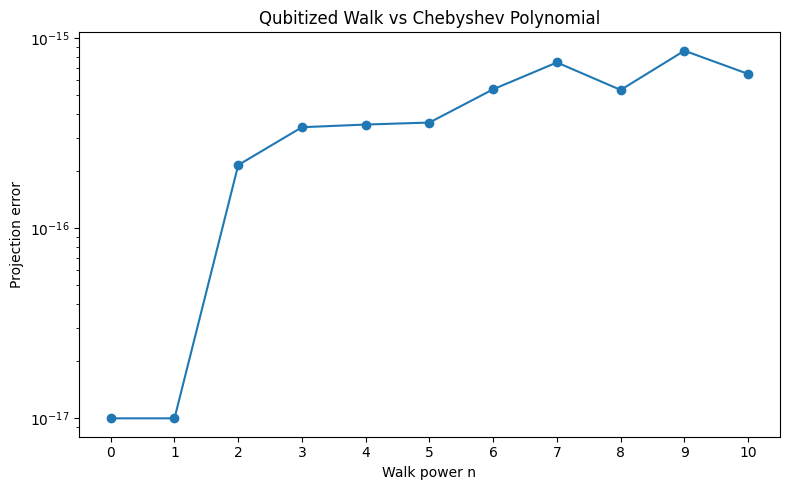

In [15]:
# 验证误差
import matplotlib.pyplot as plt

degrees = np.arange(max_degree + 1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(degrees, np.maximum(chebyshev_errors, 1e-17), marker="o")

ax.set_xlabel("Walk power n")
ax.set_ylabel("Projection error")
ax.set_title("Qubitized Walk vs Chebyshev Polynomial")

ax.set_xticks(degrees)
fig.tight_layout()

plt.show()

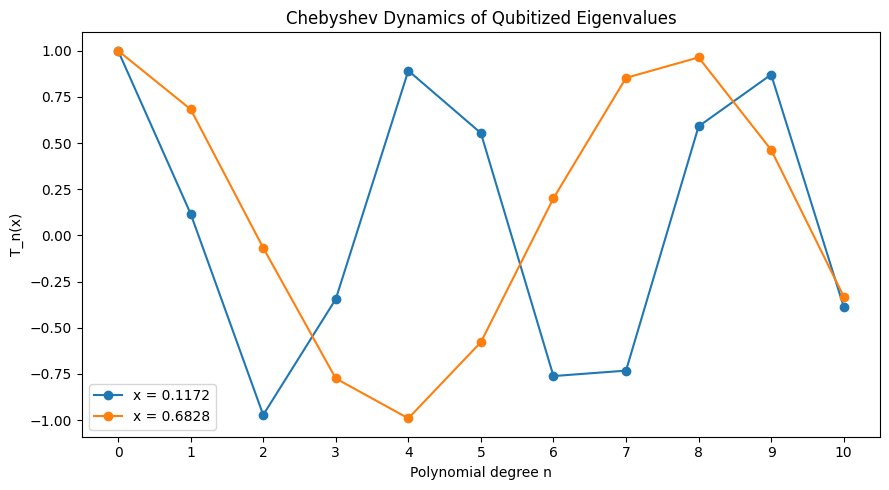

In [ ]:
# Chebyshev 演化
degrees = np.arange(11)

fig, ax = plt.subplots(figsize=(9, 5))

for x in b_eigenvalues:
    values = [np.cos(n * np.arccos(x)) for n in degrees]

    ax.plot(degrees, values, marker="o", label=f"x = {x:.4f}")

ax.set_xlabel("Polynomial degree n")
ax.set_ylabel("T_n(x)")
ax.set_title("Chebyshev Dynamics of Qubitized Eigenvalues")
ax.set_xticks(degrees)
ax.legend()

fig.tight_layout()

plt.show()